In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [6]:
class SphericalClustering(nn.Module):
    def __init__(self, num_covariates, response_dim, num_clusters, distribution = "pkbd", min_weight=0.05, device='cpu'):
        super(SphericalClustering, self).__init__()
        self.num_covariates = num_covariates
        self.response_dim = response_dim
        self.num_clusters = num_clusters
        self.min_weight = torch.tensor(min_weight)
        self.distribution = distribution
        self.device = device

        # Linear layer to map covariates X to K cluster embeddings (Cx(d*K))
        self.A = nn.Linear(num_covariates, response_dim * num_clusters, bias=False)

        # Preallocate Pi as the log of uniform probabilities (no need for .to(device))
        self.pi = torch.log(torch.ones(1, num_clusters) / num_clusters).to(device)  # Uniform Pi in log space
        # Preallocate W matrix (no need for .to(device))
        self.W = torch.zeros(1, num_clusters)  # Placeholder for the W matrix
        self.loglik = -1e10

        # Placeholder for the mask
        self.mask = torch.ones(1, num_clusters, dtype=torch.bool).to(device)
        self.mask_dynamic = torch.ones(1, num_clusters, dtype=torch.bool).to(device)

    @property
    def active_components(self):
        return torch.sum(self.mask).item()
    
    @property
    def df(self):
        return self.num_covariates * self.response_dim * self.active_components
    
    def __repr__(self):
        # Custom string representation
        details = f"Mixture of {self.distribution} Distributional Regressions with {self.active_components} components and {self.num_covariates} covariates.\n"
        details += f"Log-likelihood: {self.loglik}\n"
        details += super().__repr__()  # Include the nn.Module details
        return details

    def forward(self, X):
        # Forward pass to map covariates X to embeddings
        N = X.size(0)
        embeddings = self.A(X)  # Shape: Nx(d*K)
        embeddings = embeddings.view(N, self.num_clusters, self.response_dim)  # Shape: NxKxd
        embeddings = embeddings[:, self.mask.squeeze()]
        # Compute mu (mean direction) by normalizing across the last dimension
        norms = torch.norm(embeddings, dim=-1, keepdim=True)  # Shape: NxKx1
        mu = embeddings / norms  # Normalized embeddings: NxKxd
        
        # Compute rho by link transformation norm/(norm+1)
        rho = norms / (norms + 1)  # Shape: NxKx1
        
        return mu, rho

    def log_likelihood(self, mu, rho, Y, distribution):
        # Calculate log likelihood for each cluster
        N, K, d = mu.shape
        Y = Y.unsqueeze(2)  # Shape: Nx1xd
        cross_prod = torch.bmm(mu, Y).squeeze(-1)  # NxKx1 -> NxK
        rho = rho.squeeze(-1)  # NxKx1 -> NxK

        term1 = torch.log(1 - rho ** 2)  # NxK
        term2 = torch.log(1 + rho ** 2 - 2 * rho * cross_prod)  # NxK

        if distribution == "pkbd":
            loglik = term1 - d*term2/2 # Shape: NxK
        elif distribution == "spcauchy":
            loglik = (d-1)*term1 - (d-1)*term2  # Shape: NxK
        else:
            raise ValueError("Model must be 'pkbd' or 'spcauchy'")
        
        return loglik

    def E_step(self, loglik_detached):
        # E-step: update Pi and W based on log likelihood
        N, K = loglik_detached.shape
        # Sum log-likelihood with log Pi (since Pi is in log space)
        loglik_with_pi = loglik_detached + self.pi  # Element-wise sum with log Pi vector
        
        # Apply softmax to get W (posterior probabilities) NxK
        self.W = torch.softmax(loglik_with_pi, dim=1)

        # Update Pi by column means of W
        new_pi = torch.mean(self.W, dim=0, keepdim=True)  # Shape: 1xK

        mask2 = (new_pi >= self.min_weight)
        if torch.any(~mask2):
            removed_clusters = (torch.arange(self.num_clusters)+1).unsqueeze(0).to(self.device)[self.mask][~mask2.squeeze()].tolist()
            updated_mask = self.mask.clone()  # Clone the current mask to avoid in-place memory issues
            updated_mask[self.mask] = mask2  # Only update the active part of the original mask
            self.mask = updated_mask
            self.mask_dynamic = mask2
            loglik_with_pi = loglik_with_pi[:, mask2.squeeze()]
            self.W = torch.softmax(loglik_with_pi, dim=1)
            self.pi = torch.log(torch.mean(self.W, dim=0, keepdim=True))  
            print(f"Clusters {removed_clusters} were removed in this iteration.")
            removed = True
        else:
            self.pi = torch.log(new_pi)
            removed = False

        self.loglik = torch.logsumexp(loglik_with_pi, dim = 1).sum()

        return removed

    def M_step(self, X, Y):
        # Perform full M-step with recalculation of model parameters and multiple optimization steps
        mu, rho = self(X)
        loglik = self.log_likelihood(mu, rho, Y, self.distribution)
        # Perform backward pass based on the current W
        W_colnorm = self.W / (torch.sum(self.W, dim=0, keepdim=True))  # Column normalize W
        weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
        cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
        loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood

        return loss
    
    def fit(self, X, Y, num_epochs=100, num_inner_steps=10, lr = 1e-3, tol = 1e-4, plot = True):
        # Fit the model using EM algorithm
        X = X.to(self.device)
        Y = Y.to(self.device)
        optimizer = optim.AdamW(self.parameters(), lr=lr)

        models_loglik_old = torch.tensor(-1e10)

        Loglikelihoods = []

        self.train()
        for epoch in range(num_epochs):
            # E-step
            optimizer.zero_grad()
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_detached = loglik.detach()  # Detach the log-likelihood before the E-step
            rem = self.E_step(loglik_detached)
            if rem:
                loglik = loglik[:, self.mask_dynamic.squeeze()]
            Loglikelihoods.append(self.loglik)

            if torch.abs(self.loglik - models_loglik_old) < tol*100:
                break
            models_loglik_old = self.loglik

            # M-step
            W_colnorm = self.W / torch.sum(self.W, dim=0, keepdim=True)  # Column normalize W
            weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
            cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
            loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood
            loss.backward()
            optimizer.step()

            # Perform n-1 more M-steps with re-evaluations
            old_loss = loss.item()
            for step in range(num_inner_steps-1):
                optimizer.zero_grad()  # Reset gradients
                loss = self.M_step(X, Y)
                if abs(loss.item() - old_loss) < tol:
                    print(f'   Inner_step {step + 2}/{num_inner_steps}, Loss: {loss.item()}')
                    break
                loss.backward()
                optimizer.step()  # Update model parameters
                old_loss = loss.item()
            loss = loss.item()

            if (epoch + 1) % 1 == 0:
                print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss}, Log-likelihood: {self.loglik}')
        
        if plot:
            # plot the log-likelihoods over the epochs and return them
            if self.device == 'cuda':
                Loglikelihoods = [x.cpu().detach().numpy() for x in Loglikelihoods]
            plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
            plt.xlabel('Epochs')
            plt.ylabel('Log-likelihood')
            plt.title('Log-likelihood over epochs')
        return Loglikelihoods
    
    def get_final_W(self, dataloader):
        """
        Compute the final W matrix (posterior probabilities) for the entire dataset.

        Args:
            dataloader (DataLoader): DataLoader for the dataset (must not shuffle data).

        Returns:
            torch.Tensor: The final W matrix of shape (N, K).
        """
        self.eval()  # Set the model to evaluation mode
        W_list = []
        ll = 0

        with torch.no_grad():
            for batch in dataloader:
                X_batch, Y_batch = batch
                X_batch = X_batch.to(self.device)
                Y_batch = Y_batch.to(self.device)

                # Forward pass
                mu, rho = self(X_batch)
                loglik = self.log_likelihood(mu, rho, Y_batch)
                
                # Compute loglikelihood with current Pi (in log space)
                loglik_with_pi = loglik + self.pi  # self.pi is in log space

                # Compute W for this batch
                W_batch = torch.softmax(loglik_with_pi, dim=1)
                # Final log-likelihood
                ll += torch.logsumexp(loglik_with_pi, dim = 1).sum()
                # Append W_batch to W_list
                W_list.append(W_batch)

        # Concatenate W_list to get full W matrix
        self.loglik = ll
        self.W = torch.cat(W_list, dim=0)  # Shape: (N, K)
        self.pi = torch.log(torch.mean(self.W, dim=0, keepdim=True))  # Update Pi
        return None

    

    def fit_dataloader(self, dataloader, num_epochs=100, num_inner_steps=10, lr = 1e-3, tol = 1e-4, plot = True):
        # Fit the model using EM algorithm
        optimizer = optim.AdamW(self.parameters(), lr=lr)
        models_loglik_old = torch.tensor(-1e10)
        Loglikelihoods = []

        self.train()
        for epoch in range(num_epochs):
            epoch_loglik = 0
            epoch_loss = 0
            for batch_idx, batch in enumerate(dataloader):
                # E-step
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)

                optimizer.zero_grad()
                mu, rho = self(X)
                loglik = self.log_likelihood(mu, rho, Y, self.distribution)
                loglik_detached = loglik.detach()  # Detach the log-likelihood before the E-step
                rem = self.E_step(loglik_detached)
                if rem:
                    loglik = loglik[:, self.mask_dynamic.squeeze()]
                epoch_loglik += self.loglik    

                # M-step
                W_colnorm = self.W / torch.sum(self.W, dim=0, keepdim=True)  # Column normalize W
                weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
                cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
                loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood
                loss.backward()
                optimizer.step()

                # Perform n-1 more M-steps with re-evaluations
                old_loss = loss.item()
                for step in range(num_inner_steps-1):
                    optimizer.zero_grad()  # Reset gradients
                    loss = self.M_step(X, Y)
                    if abs(loss.item() - old_loss) < tol:
                        print(f'   Inner_step {step + 2}/{num_inner_steps}, Loss: {loss.item()}')
                        break
                    loss.backward()
                    optimizer.step()  # Update model parameters
                    old_loss = loss.item()
                loss = loss.item()
                epoch_loss += loss
                print(f'Batch {batch_idx + 1}/{len(dataloader)}, Loss: {loss}')

            self.loglik = epoch_loglik
            Loglikelihoods.append(self.loglik)
            if torch.abs(self.loglik - models_loglik_old) < tol*100:
                break
            models_loglik_old = self.loglik    

            if (epoch + 1) % 1 == 0:
                print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss}, Log-likelihood: {self.loglik}')

        self.get_final_W(dataloader)

        if plot:
            # plot the log-likelihoods over the epochs and return them
            if self.device == 'cuda':
                Loglikelihoods = [x.cpu().detach().numpy() for x in Loglikelihoods]
            plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
            plt.xlabel('Epochs')
            plt.ylabel('Log-likelihood')
            plt.title('Log-likelihood over epochs')
        return Loglikelihoods
    
    def predict(self, X):
        # Predict the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            return self(X)

    def predict_and_cluster(self, X, Y):
        # Predict the cluster assignments and return the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            Y = Y.to(self.device)
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_with_pi = loglik + self.pi  # Element-wise sum with log Pi vector
            posterior = torch.softmax(loglik_with_pi, dim=1)
            return posterior, mu, rho
                  
       

In [7]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = "cpu"
N, C, d, K = 200, 2, 1024, 6  # Example dimensions
X = torch.randn(N, C)  # Covariates NxC
Y = torch.randn(N, d)  # Response Nxd
Y = Y / torch.norm(Y, dim=1, keepdim=True)  # Normalize Y

model = SphericalClustering(num_covariates=C, response_dim=d, num_clusters=K, device=device)
model.to(device)  # Move the entire model to the device

Mixture of pkbd Distributional Regressions with 6 components and 2 covariates.
Log-likelihood: -10000000000.0
SphericalClustering(
  (A): Linear(in_features=2, out_features=6144, bias=False)
)

Epoch 1/100, Loss: 292.44989013671875, Log-likelihood: -59764.51953125
Epoch 2/100, Loss: 286.48089599609375, Log-likelihood: -58677.80859375
Epoch 3/100, Loss: 280.57855224609375, Log-likelihood: -57553.89453125
Epoch 4/100, Loss: 274.7724914550781, Log-likelihood: -56410.1015625
Epoch 5/100, Loss: 268.9380187988281, Log-likelihood: -55261.546875
Epoch 6/100, Loss: 263.0563049316406, Log-likelihood: -54104.05078125
Epoch 7/100, Loss: 257.1475524902344, Log-likelihood: -52939.58203125
Epoch 8/100, Loss: 251.19346618652344, Log-likelihood: -51767.9140625
Epoch 9/100, Loss: 245.1833953857422, Log-likelihood: -50586.765625
Epoch 10/100, Loss: 239.1078338623047, Log-likelihood: -49394.046875
Epoch 11/100, Loss: 232.9566192626953, Log-likelihood: -48187.8515625
Epoch 12/100, Loss: 226.7174530029297, Log-likelihood: -46966.0625
Epoch 13/100, Loss: 220.3747100830078, Log-likelihood: -45726.0546875
Epoch 14/100, Loss: 213.9081268310547, Log-likelihood: -44464.4765625
Epoch 15/100, Loss: 207.29

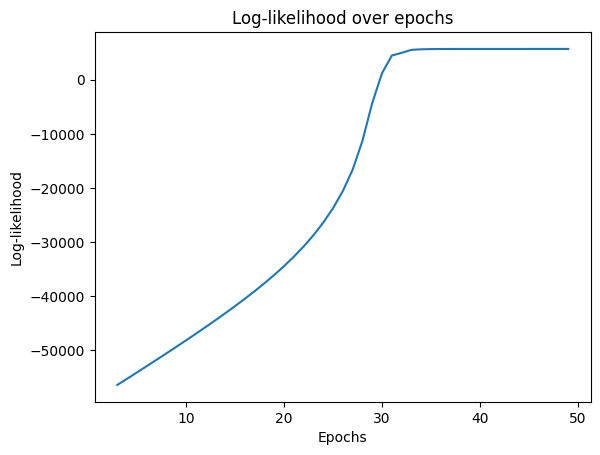

In [8]:
loglikkkks = model.fit(X, Y, num_epochs=100, num_inner_steps=20, lr=1e-3)

In [9]:
model

Mixture of pkbd Distributional Regressions with 5 components and 2 covariates.
Log-likelihood: 5685.8388671875
SphericalClustering(
  (A): Linear(in_features=2, out_features=6144, bias=False)
)